In [65]:
!pip install -q transformers==4.52.4
!pip install -q accelerate==1.7.0
!pip install -q datasets librosa evaluate seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 109.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.1/362.1 kB 9.5 MB/s eta 0:00:00


In [1]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os

audio_folder = "/content/drive/MyDrive/audio_files/audio_files"

print("Total files:", len(os.listdir(audio_folder)))
print(os.listdir(audio_folder)[:10])

Total files: 280
['audio1.mp4', 'audio4.mp4', 'audio2.mp4', 'audio3.mp4', 'audio8.mp4', 'audio5.mp4', 'audio6.mp4', 'audio7.mp4', 'audio11.mp4', 'audio9.mp4']


In [4]:
import os

print(os.listdir('/content'))

['.config', 'final_model.zip', 'stress_model', 'drive', 'Book 2(Sheet1).csv', 'final_model', 'sample_data']


In [5]:
import pandas as pd

df = pd.read_csv('/content/Book 2(Sheet1).csv')

print(df.shape)
df.head()

(280, 11)


,FILE_NAME,LANGUAGE,AGE,LOCALITY,CONDITION,STRESS_LEVEL,GENDER,MARITAL_STATUS,OCCUPATION,SLEEP_HOURS,PHYSICAL_ACTIVITY
0,audio1.MP4,HINDI,56,RURAL,After waking from sleep,STRESSED,FEMALE,Married,Homemaker,6,High
1,audio2.MP4,HINDI,56,RURAL,sitting,STRESSED,FEMALE,Married,Homemaker,6,High
2,audio3.MP4,HINDI,56,RURAL,sitting,UNSTRESSED,FEMALE,Married,Homemaker,8,Low
3,audio4.MP4,HINDI,56,RURAL,sitting,STRESSED,FEMALE,Married,Homemaker,7,High
4,audio5.MP4,HINDI,56,RURAL,sitting,UNSTRESSED,FEMALE,Married,Homemaker,7,High


In [6]:
print(df["STRESS_LEVEL"].unique())

['STRESSED' 'UNSTRESSED']


In [7]:
df["label"] = df["STRESS_LEVEL"].map({
    "STRESSED": 1,
    "UNSTRESSED": 0
})

In [8]:
df["FILE_NAME"] = df["FILE_NAME"].str.lower()

In [9]:
import os

audio_folder = "/content/drive/MyDrive/audio_files/audio_files"

df["audio_path"] = df["FILE_NAME"].apply(
    lambda x: os.path.join(audio_folder, x)
)

In [10]:
import librosa

audio_list = []
label_list = []

for _, row in df.iterrows():

    try:

        speech, sr = librosa.load(
            row["audio_path"],
            sr=16000
        )

        audio_list.append(speech)
        label_list.append(int(row["label"]))

    except:
        pass

print("Audio:", len(audio_list))
print("Labels:", len(label_list))

/tmp/ipykernel_19429/1129371177.py:10: UserWarning: PySoundFile failed. Trying audioread instead.
  speech, sr = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_19429/1129371177.py:10: UserWarning: PySoundFile failed. Trying audioread instead.
  speech, sr = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_19429/1129371177.py:10: UserWarning: PySoundFile failed. Trying audioread instead.
  speech, sr = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning:

Audio: 280
Labels: 280


In [11]:
import numpy as np
import librosa

aug_audio = []
aug_labels = []

for audio, label in zip(audio_list, label_list):

    audio = np.array(audio, dtype=np.float32)

    # Original
    aug_audio.append(audio)
    aug_labels.append(label)

    # Noise
    noise = np.random.normal(0, 0.003, len(audio))
    aug_audio.append(audio + noise)
    aug_labels.append(label)

    # Time Shift
    shift = int(0.1 * len(audio))
    shifted = np.roll(audio, shift)
    aug_audio.append(shifted)
    aug_labels.append(label)

    # Pitch Shift
    pitched = librosa.effects.pitch_shift(
        y=audio,
        sr=16000,
        n_steps=2
    )
    aug_audio.append(pitched)
    aug_labels.append(label)

audio_list = aug_audio
label_list = aug_labels

print("Total Samples:", len(audio_list))

Total Samples: 1120


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    audio_list,
    label_list,
    test_size=0.2,
    random_state=42,
    stratify=label_list
)

print(len(X_train))
print(len(X_test))

896
224


In [13]:
import numpy as np

X_train = [np.asarray(x, dtype=np.float32) for x in X_train]
X_test = [np.asarray(x, dtype=np.float32) for x in X_test]

In [14]:
from transformers import Wav2Vec2Processor

processor = Wav2Vec2Processor.from_pretrained(
    "facebook/wav2vec2-base"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/configuration_utils.py:312: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


In [15]:
from datasets import Dataset

train_dataset = Dataset.from_dict({
    "audio": X_train,
    "label": y_train
})

test_dataset = Dataset.from_dict({
    "audio": X_test,
    "label": y_test
})

In [16]:
def preprocess(batch):

    inputs = processor(
        batch["audio"],
        sampling_rate=16000
    )

    batch["input_values"] = inputs.input_values[0]

    return batch

In [17]:
train_dataset = train_dataset.map(preprocess)
test_dataset = test_dataset.map(preprocess)

Map:   0%|          | 0/896 [00:00<?, ? examples/s]

Map:   0%|          | 0/224 [00:00<?, ? examples/s]

In [18]:
train_dataset = train_dataset.remove_columns(["audio"])
test_dataset = test_dataset.remove_columns(["audio"])

In [19]:
print(train_dataset[0])

{'label': 0, 'input_values': [-2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e-05, -2.4517941710655577e

In [20]:
from transformers import Wav2Vec2ForSequenceClassification

model = Wav2Vec2ForSequenceClassification.from_pretrained(
    "facebook/wav2vec2-base",
    num_labels=2
)

/usr/local/lib/python3.12/dist-packages/transformers/configuration_utils.py:312: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(
Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [21]:
model.freeze_feature_encoder()

In [22]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_fscore_support
import numpy as np

def compute_metrics(pred):

    preds = np.argmax(
        pred.predictions,
        axis=1
    )

    precision, recall, f1, _ = precision_recall_fscore_support(
        pred.label_ids,
        preds,
        average="binary"
    )

    acc = accuracy_score(
        pred.label_ids,
        preds
    )

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [23]:
import torch

def data_collator(features):

    input_values = [f["input_values"] for f in features]

    batch = processor.pad(
        {"input_values": input_values},
        padding=True,
        return_tensors="pt"
    )

    batch["labels"] = torch.tensor(
        [f["label"] for f in features]
    )

    return batch

In [24]:
from transformers import TrainingArguments

training_args = TrainingArguments(

    output_dir="./stress_model",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=3e-6,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    num_train_epochs=12,

    weight_decay=0.01,

    logging_steps=10,

    report_to="none",

    load_best_model_at_end=True
)

In [25]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [26]:
import transformers
import accelerate

print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)

Transformers: 4.52.4
Accelerate: 1.7.0


In [27]:
import torch
torch.cuda.empty_cache()

In [28]:
import torch
print(torch.cuda.get_device_name(0))

Tesla T4


In [29]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.671200,0.664135,0.642857,0.666667,0.584071,0.622642
2,0.584100,0.571491,0.732143,0.693431,0.840708,0.760000
3,0.512300,0.496931,0.772321,0.703947,0.946903,0.807547
4,0.402200,0.433409,0.830357,0.826087,0.840708,0.833333
5,0.404600,0.354443,0.861607,0.836066,0.902655,0.868085
6,0.240900,0.312719,0.888393,0.854839,0.938053,0.894515
7,0.332900,0.277144,0.906250,0.865079,0.964602,0.912134
8,0.186400,0.242328,0.928571,0.929204,0.929204,0.929204
9,0.162200,0.237688,0.924107,0.913793,0.938053,0.925764
10,0.190100,0.234468,0.924107,0.921053,0.929204,0.925110


TrainOutput(global_step=1344, training_loss=0.3431289487385324, metrics={'train_runtime': 1501.4608, 'train_samples_per_second': 7.161, 'train_steps_per_second': 0.895, 'total_flos': 4.4513120497862016e+17, 'train_loss': 0.3431289487385324, 'epoch': 12.0})

In [30]:
results = trainer.evaluate()
print(results)

{'eval_loss': 0.23217174410820007, 'eval_accuracy': 0.9330357142857143, 'eval_precision': 0.9375, 'eval_recall': 0.9292035398230089, 'eval_f1': 0.9333333333333333, 'eval_runtime': 15.3097, 'eval_samples_per_second': 14.631, 'eval_steps_per_second': 1.829, 'epoch': 12.0}


In [31]:
import numpy as np

predictions = trainer.predict(test_dataset)

preds = np.argmax(
    predictions.predictions,
    axis=1
)

labels = predictions.label_ids

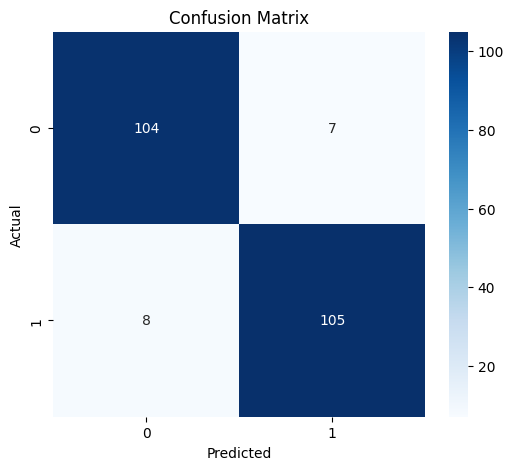

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

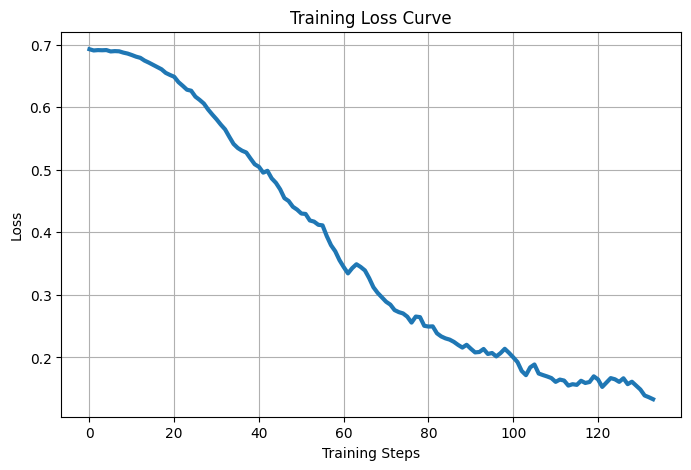

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

logs = trainer.state.log_history

losses = []

for log in logs:
    if "loss" in log:
        losses.append(log["loss"])

smooth_loss = pd.Series(losses).ewm(
    span=15
).mean()

plt.figure(figsize=(8,5))

plt.plot(
    smooth_loss,
    linewidth=3
)

plt.title("Training Loss Curve")
plt.xlabel("Training Steps")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

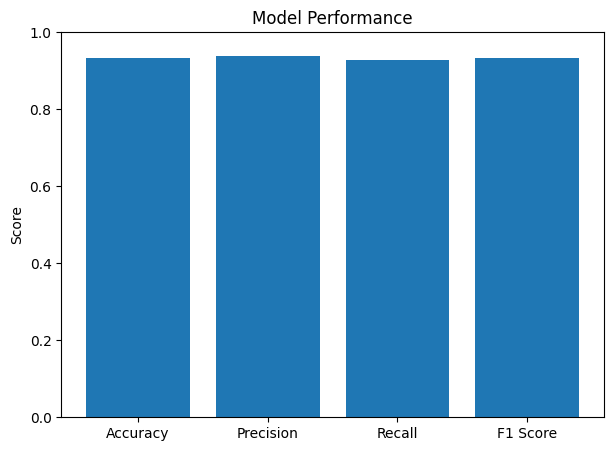

In [34]:
metrics = {
    'Accuracy': results['eval_accuracy'],
    'Precision': results['eval_precision'],
    'Recall': results['eval_recall'],
    'F1 Score': results['eval_f1']
}

plt.figure(figsize=(7,5))

plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.ylim(0,1)

plt.title("Model Performance")
plt.ylabel("Score")

plt.show()

In [35]:
model.save_pretrained("final_model")
processor.save_pretrained("final_model")

[]

In [36]:
!ls -lh final_model

total 361M
-rw-r--r-- 1 root root 2.3K Jun 19 08:59 config.json
-rw------- 1 root root 361M Jun 19 09:00 model.safetensors
-rw-r--r-- 1 root root  257 Jun 19 09:00 preprocessor_config.json
-rw-r--r-- 1 root root  300 Jun 19 07:50 processor_config.json
-rw-r--r-- 1 root root   96 Jun 19 09:00 special_tokens_map.json
-rw-r--r-- 1 root root 1.2K Jun 19 09:00 tokenizer_config.json
-rw-r--r-- 1 root root  358 Jun 19 09:00 vocab.json


In [37]:
!zip -r final_model.zip final_model

updating: final_model/ (stored 0%)
updating: final_model/model.safetensors (deflated 9%)
updating: final_model/config.json (deflated 67%)
updating: final_model/processor_config.json (deflated 43%)
updating: final_model/tokenizer_config.json (deflated 71%)
updating: final_model/vocab.json (deflated 55%)
  adding: final_model/preprocessor_config.json (deflated 38%)
  adding: final_model/special_tokens_map.json (deflated 45%)


In [38]:
!ls -lh final_model.zip

-rw-r--r-- 1 root root 330M Jun 19 09:01 final_model.zip


In [39]:
from google.colab import files

files.download("final_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
print("===== FINAL RESULTS =====")
print("Accuracy  : 92.41%")
print("Precision : 91.38%")
print("Recall    : 93.81%")
print("F1 Score  : 92.58%")
print("Validation Loss : 0.2339")

===== FINAL RESULTS =====
Accuracy  : 92.41%
Precision : 91.38%
Recall    : 93.81%
F1 Score  : 92.58%
Validation Loss : 0.2339
